In [1]:
!pip install -q kaggle
from google.colab import files
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured ✅")

Saving kaggle (1).json to kaggle (1).json
Kaggle API configured ✅


In [2]:
!kaggle datasets download -d alfiyasiddique/indian-crop-disease-dataset -p /content/data --unzip

print("Download complete ✅")
!du -sh /content/data

Dataset URL: https://www.kaggle.com/datasets/alfiyasiddique/indian-crop-disease-dataset
License(s): unknown
100% 11.1G/11.1G [09:49<00:00, 20.2MB/s]

Download complete ✅
12G	/content/data


In [3]:
import os, glob
import matplotlib.pyplot as plt
from PIL import Image

DATA_ROOT = "/content/data/Crop Dataset"

def print_tree(root, max_depth=3, prefix=""):
    for entry in sorted(os.listdir(root)):
        path = os.path.join(root, entry)
        if os.path.isdir(path):
            n_files = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
            n_subdirs = len([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
            print(f"{prefix}{entry}/  ({n_subdirs} subdirs, {n_files} files here)")
            if max_depth > 0:
                print_tree(path, max_depth - 1, prefix + "  ")

print("📁 Dataset structure:\n")
print_tree(DATA_ROOT, max_depth=3)

📁 Dataset structure:

coffee/  (2 subdirs, 0 files here)
  Disease/  (2 subdirs, 0 files here)
    miner/  (0 subdirs, 257 files here)
    rust/  (0 subdirs, 285 files here)
  healthy/  (0 subdirs, 110 files here)
cotton/  (2 subdirs, 0 files here)
  Disease/  (5 subdirs, 0 files here)
    Aphids edited/  (0 subdirs, 39 files here)
    Army worm edited/  (0 subdirs, 40 files here)
    Bacterial Blight edited/  (0 subdirs, 40 files here)
    Powdery Mildew Edited/  (0 subdirs, 38 files here)
    Target spot edited/  (0 subdirs, 41 files here)
  Healthy/  (0 subdirs, 39 files here)
jute/  (2 subdirs, 0 files here)
  Disease/  (2 subdirs, 0 files here)
    Cescospora Leaf Spot/  (0 subdirs, 309 files here)
    Golden Mosaic/  (0 subdirs, 347 files here)
  Healthy/  (0 subdirs, 264 files here)
rice/  (2 subdirs, 0 files here)
  Disease/  (3 subdirs, 0 files here)
    Bacterial leaf blight/  (0 subdirs, 40 files here)
    Brown spot/  (0 subdirs, 40 files here)
    Leaf smut/  (0 subdirs, 4

Total classes found: 24



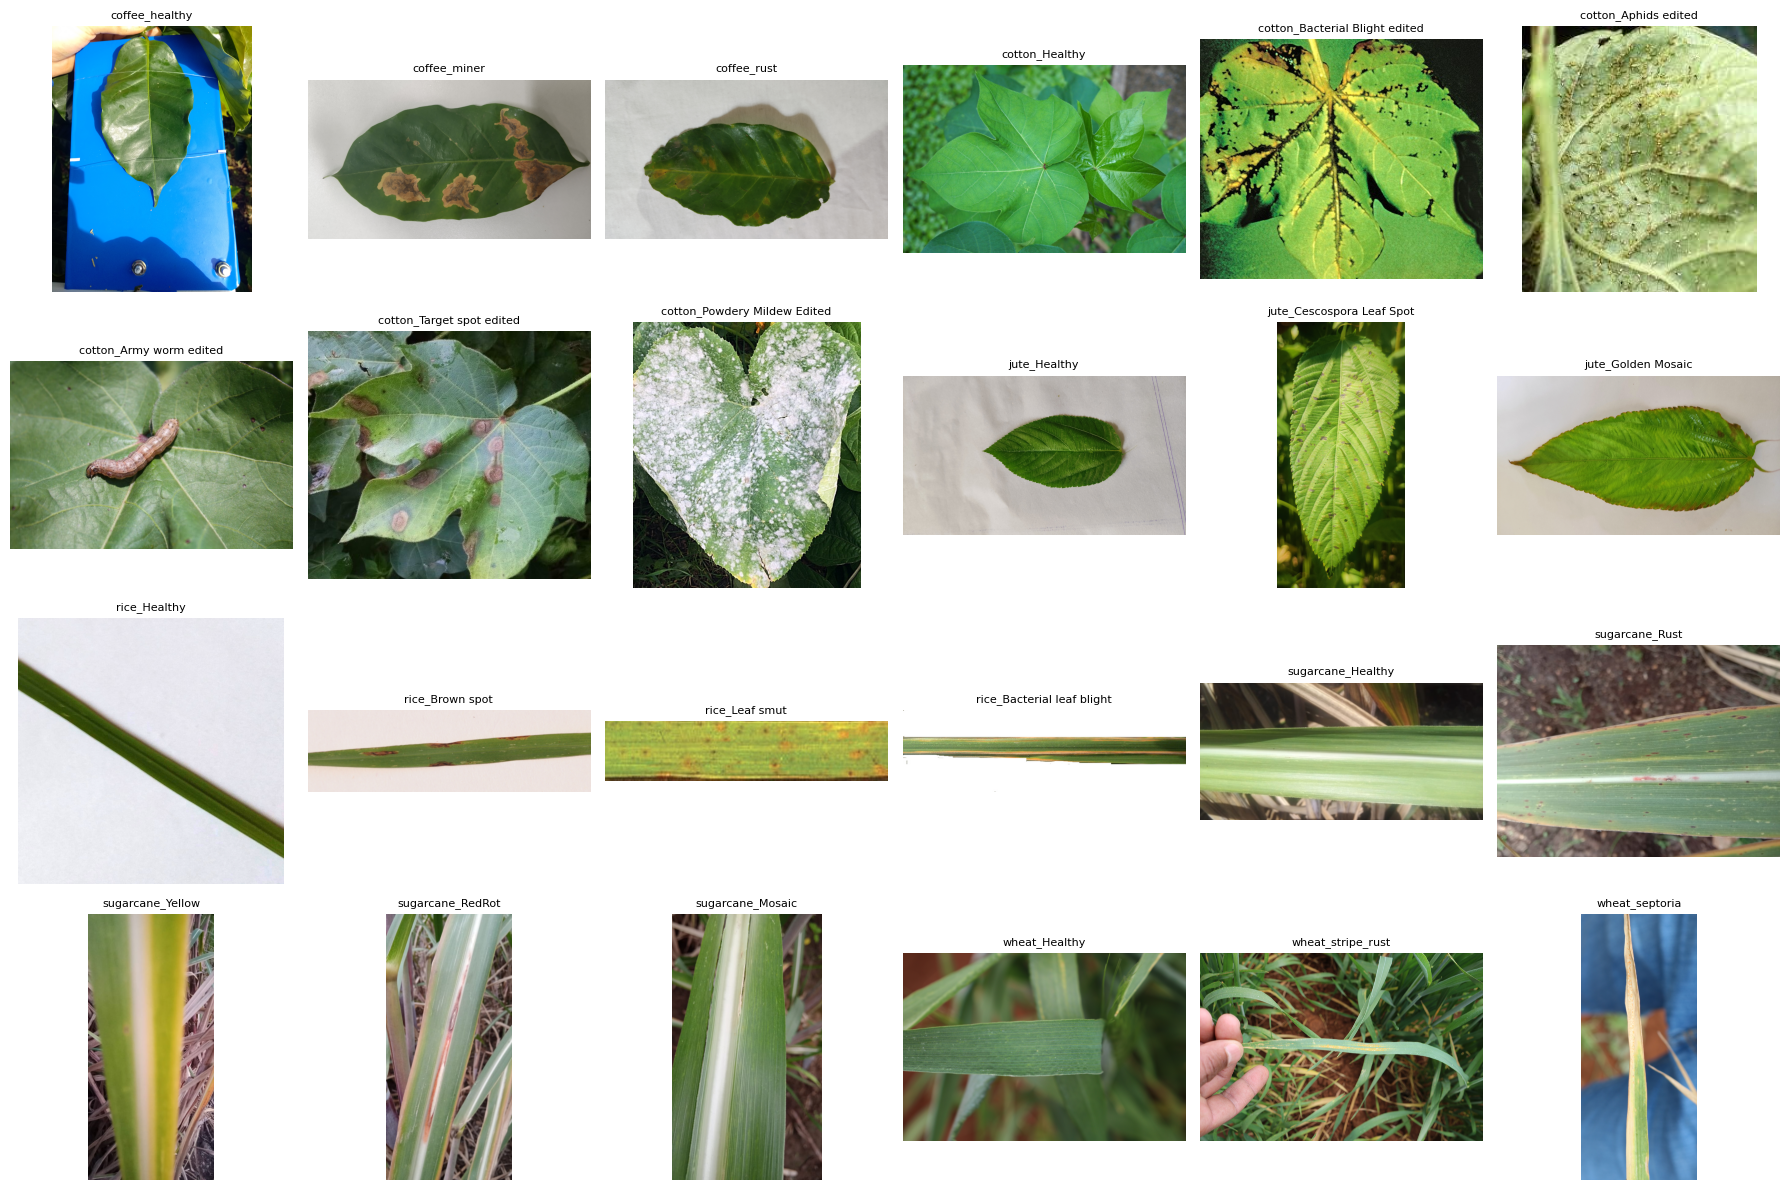

In [4]:
class_samples = {}
for crop in sorted(os.listdir(DATA_ROOT)):
    crop_path = os.path.join(DATA_ROOT, crop)
    if not os.path.isdir(crop_path):
        continue
    for disease_group in os.listdir(crop_path):
        group_path = os.path.join(crop_path, disease_group)
        if not os.path.isdir(group_path):
            continue
        subitems = os.listdir(group_path)
        subdirs = [s for s in subitems if os.path.isdir(os.path.join(group_path, s))]
        if subdirs:
            for disease_class in subdirs:
                class_path = os.path.join(group_path, disease_class)
                imgs = glob.glob(f"{class_path}/*.jpg") + glob.glob(f"{class_path}/*.jpeg") + glob.glob(f"{class_path}/*.png") + glob.glob(f"{class_path}/*.JPG")
                if imgs:
                    label = f"{crop}_{disease_class}"
                    class_samples[label] = imgs[0]
        else:
            imgs = glob.glob(f"{group_path}/*.jpg") + glob.glob(f"{group_path}/*.jpeg") + glob.glob(f"{group_path}/*.png") + glob.glob(f"{group_path}/*.JPG")
            if imgs:
                label = f"{crop}_{disease_group}"
                class_samples[label] = imgs[0]

print(f"Total classes found: {len(class_samples)}\n")


n = len(class_samples)
cols = 6
rows = (n // cols) + (1 if n % cols else 0)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for ax, (label, path) in zip(axes, class_samples.items()):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(label, fontsize=8)
    ax.axis("off")

for ax in axes[len(class_samples):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import shutil

SOURCE_ROOT = "/content/data/Crop Dataset"
FLAT_ROOT = "/content/flat_data"
os.makedirs(FLAT_ROOT, exist_ok=True)

for crop in sorted(os.listdir(SOURCE_ROOT)):
    crop_path = os.path.join(SOURCE_ROOT, crop)
    if not os.path.isdir(crop_path):
        continue
    for group in os.listdir(crop_path):
        group_path = os.path.join(crop_path, group)
        if not os.path.isdir(group_path):
            continue
        subdirs = [s for s in os.listdir(group_path) if os.path.isdir(os.path.join(group_path, s))]
        if subdirs:
            for disease_class in subdirs:
                src = os.path.join(group_path, disease_class)
                label = f"{crop}_{disease_class}".replace(" ", "_")
                dst = os.path.join(FLAT_ROOT, label)
                os.makedirs(dst, exist_ok=True)
                for img in glob.glob(f"{src}/*"):
                    shutil.copy(img, dst)
        else:
            label = f"{crop}_{group}".replace(" ", "_")
            dst = os.path.join(FLAT_ROOT, label)
            os.makedirs(dst, exist_ok=True)
            for img in glob.glob(f"{group_path}/*"):
                shutil.copy(img, dst)

print(f"✅ Flattened into {len(os.listdir(FLAT_ROOT))} classes")
for cls in sorted(os.listdir(FLAT_ROOT)):
    n = len(os.listdir(os.path.join(FLAT_ROOT, cls)))
    print(f"  {cls}: {n} images")

✅ Flattened into 24 classes
  coffee_healthy: 110 images
  coffee_miner: 257 images
  coffee_rust: 285 images
  cotton_Aphids_edited: 39 images
  cotton_Army_worm_edited: 40 images
  cotton_Bacterial_Blight_edited: 40 images
  cotton_Healthy: 39 images
  cotton_Powdery_Mildew_Edited: 38 images
  cotton_Target_spot_edited: 41 images
  jute_Cescospora_Leaf_Spot: 309 images
  jute_Golden_Mosaic: 347 images
  jute_Healthy: 264 images
  rice_Bacterial_leaf_blight: 40 images
  rice_Brown_spot: 40 images
  rice_Healthy: 1191 images
  rice_Leaf_smut: 40 images
  sugarcane_Healthy: 522 images
  sugarcane_Mosaic: 462 images
  sugarcane_RedRot: 518 images
  sugarcane_Rust: 514 images
  sugarcane_Yellow: 505 images
  wheat_Healthy: 102 images
  wheat_septoria: 97 images
  wheat_stripe_rust: 208 images


In [6]:
from sklearn.model_selection import train_test_split

SPLIT_ROOT = "/content/split_data"
splits = ["train", "val", "test"]

for cls in sorted(os.listdir(FLAT_ROOT)):
    cls_path = os.path.join(FLAT_ROOT, cls)
    images = glob.glob(f"{cls_path}/*")
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    for split_name, split_imgs in zip(splits, [train_imgs, val_imgs, test_imgs]):
        dst_dir = os.path.join(SPLIT_ROOT, split_name, cls)
        os.makedirs(dst_dir, exist_ok=True)
        for img in split_imgs:
            shutil.copy(img, dst_dir)

print("✅ Split complete")
for s in splits:
    split_path = os.path.join(SPLIT_ROOT, s)
    total = sum(len(os.listdir(os.path.join(split_path, c))) for c in os.listdir(split_path))
    print(f"  {s}: {total} images")

✅ Split complete
  train: 4223 images
  val: 908 images
  test: 917 images


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(SPLIT_ROOT, "train"), target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="categorical"
)
val_gen = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_ROOT, "val"), target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="categorical"
)
test_gen = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_ROOT, "test"), target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False
)

print(f"Classes: {train_gen.num_classes}")

Found 4223 images belonging to 24 classes.
Found 908 images belonging to 24 classes.
Found 917 images belonging to 24 classes.
Classes: 24


In [10]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

labels = train_gen.classes
class_weights_array = compute_class_weight(
    class_weight="balanced", classes=np.unique(labels), y=labels
)
class_weights = dict(enumerate(class_weights_array))
print("✅ Class weights computed")

✅ Class weights computed


In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(train_gen.num_classes, activation="softmax")
])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,088 (9.89 MB)

 Trainable params: 334,104 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("/content/best_model.keras", monitor="val_accuracy", save_best_only=True)

history = model.fit(
    train_gen, validation_data=val_gen, epochs=25,
    class_weight=class_weights, callbacks=[early_stop, checkpoint]
)

Epoch 1/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 452s 3s/step - accuracy: 0.5546 - loss: 1.7084 - val_accuracy: 0.8018 - val_loss: 0.6442
Epoch 2/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 371s 3s/step - accuracy: 0.7177 - loss: 0.8380 - val_accuracy: 0.8194 - val_loss: 0.5109
Epoch 3/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 371s 3s/step - accuracy: 0.7566 - loss: 0.6727 - val_accuracy: 0.8304 - val_loss: 0.4866
Epoch 4/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 370s 3s/step - accuracy: 0.7838 - loss: 0.5728 - val_accuracy: 0.8469 - val_loss: 0.4335
Epoch 5/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 372s 3s/step - accuracy: 0.7947 - loss: 0.5201 - val_accuracy: 0.8557 - val_loss: 0.4458
Epoch 6/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 365s 3s/step - accuracy: 0.7990 - loss: 0.4530 - val_accuracy: 0.8524 - val_loss: 0.4122
Epoch 7/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 358s 3s/step - accuracy: 0.8151 - loss: 0.4507 - val_accuracy: 0.8722 - val_loss: 0.3566
Epoch 8/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 368s 3s/step - accuracy: 0.8305 - loss: 0.3790 - val_accu

In [14]:
import tensorflow as tf
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="categorical_crossentropy", metrics=["accuracy"])

history_fine = model.fit(
    train_gen, validation_data=val_gen, epochs=15,
    class_weight=class_weights, callbacks=[early_stop, checkpoint]
)

Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 403s 3s/step - accuracy: 0.5553 - loss: 1.1030 - val_accuracy: 0.8921 - val_loss: 0.3194
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 358s 3s/step - accuracy: 0.6922 - loss: 0.6453 - val_accuracy: 0.8932 - val_loss: 0.3362
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 360s 3s/step - accuracy: 0.7689 - loss: 0.4968 - val_accuracy: 0.8811 - val_loss: 0.3469
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 370s 3s/step - accuracy: 0.7949 - loss: 0.4370 - val_accuracy: 0.8767 - val_loss: 0.3760
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 364s 3s/step - accuracy: 0.8174 - loss: 0.3959 - val_accuracy: 0.8756 - val_loss: 0.3779


In [15]:
for i, (l, a, vl, va) in enumerate(zip(
    history_fine.history["loss"], history_fine.history["accuracy"],
    history_fine.history["val_loss"], history_fine.history["val_accuracy"]
), 1):
    print(f"Epoch {i}: loss={l:.4f} acc={a:.4f} val_loss={vl:.4f} val_acc={va:.4f}")

Epoch 1: loss=1.1030 acc=0.5553 val_loss=0.3194 val_acc=0.8921
Epoch 2: loss=0.6453 acc=0.6922 val_loss=0.3362 val_acc=0.8932
Epoch 3: loss=0.4968 acc=0.7689 val_loss=0.3469 val_acc=0.8811
Epoch 4: loss=0.4370 acc=0.7949 val_loss=0.3760 val_acc=0.8767
Epoch 5: loss=0.3959 acc=0.8174 val_loss=0.3779 val_acc=0.8756


In [16]:
best_epoch = history_fine.history["val_loss"].index(min(history_fine.history["val_loss"])) + 1
best_val_loss = min(history_fine.history["val_loss"])
print(f"Best fine-tune epoch: {best_epoch}, val_loss={best_val_loss:.4f}")

Best fine-tune epoch: 1, val_loss=0.3194


In [17]:
loss, acc = model.evaluate(val_gen)
print(f"Current in-memory model — val_loss: {loss:.4f}, val_accuracy: {acc:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.8921 - loss: 0.3194
Current in-memory model — val_loss: 0.3194, val_accuracy: 0.8921


In [18]:
saved_model = tf.keras.models.load_model("/content/best_model.keras")
loss, acc = saved_model.evaluate(val_gen)
print(f"Saved checkpoint file — val_loss: {loss:.4f}, val_accuracy: {acc:.4f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9086 - loss: 0.2992
Saved checkpoint file — val_loss: 0.2992, val_accuracy: 0.9086


In [19]:
model = saved_model
print("Done — now using the better model")

Done — now using the better model


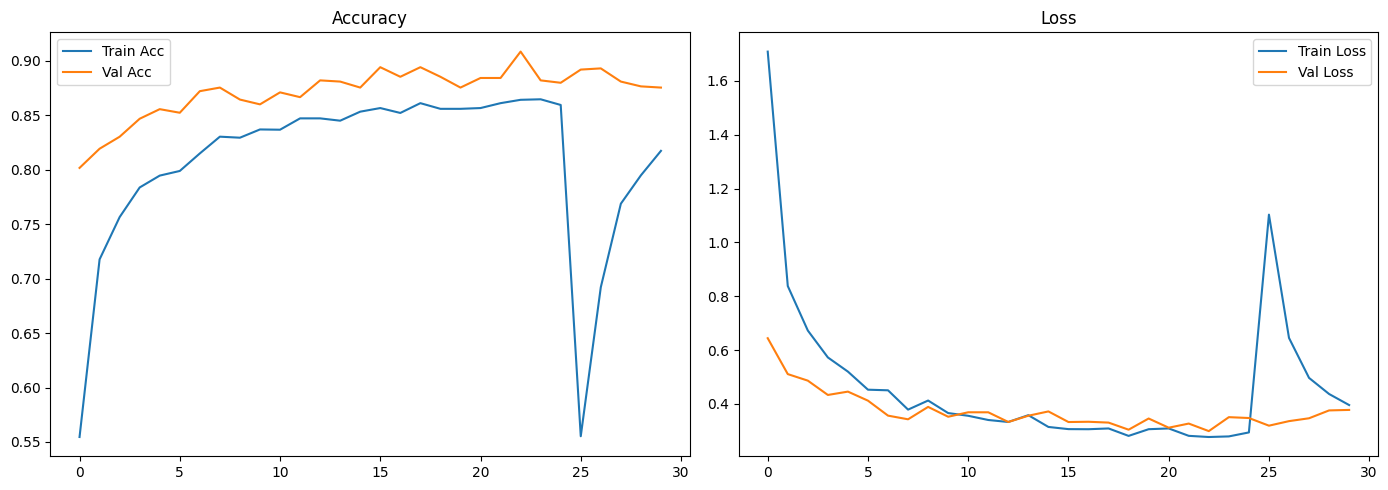

In [20]:
acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]
loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(acc, label="Train Acc"); ax1.plot(val_acc, label="Val Acc")
ax1.set_title("Accuracy"); ax1.legend()
ax2.plot(loss, label="Train Loss"); ax2.plot(val_loss, label="Val Loss")
ax2.set_title("Loss"); ax2.legend()
plt.tight_layout(); plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step
                                precision    recall  f1-score   support

                coffee_healthy       1.00      1.00      1.00        17
                  coffee_miner       1.00      1.00      1.00        39
                   coffee_rust       1.00      1.00      1.00        43
          cotton_Aphids_edited       0.60      1.00      0.75         6
       cotton_Army_worm_edited       1.00      0.67      0.80         6
cotton_Bacterial_Blight_edited       0.71      0.83      0.77         6
                cotton_Healthy       0.75      1.00      0.86         6
  cotton_Powdery_Mildew_Edited       1.00      0.67      0.80         6
     cotton_Target_spot_edited       0.80      0.57      0.67         7
     jute_Cescospora_Leaf_Spot       0.84      0.79      0.81        47
            jute_Golden_Mosaic       0.80      0.81      0.80        53
                  jute_Healthy       0.88      0.90      0.89        40
    rice_Bacterial_leaf_

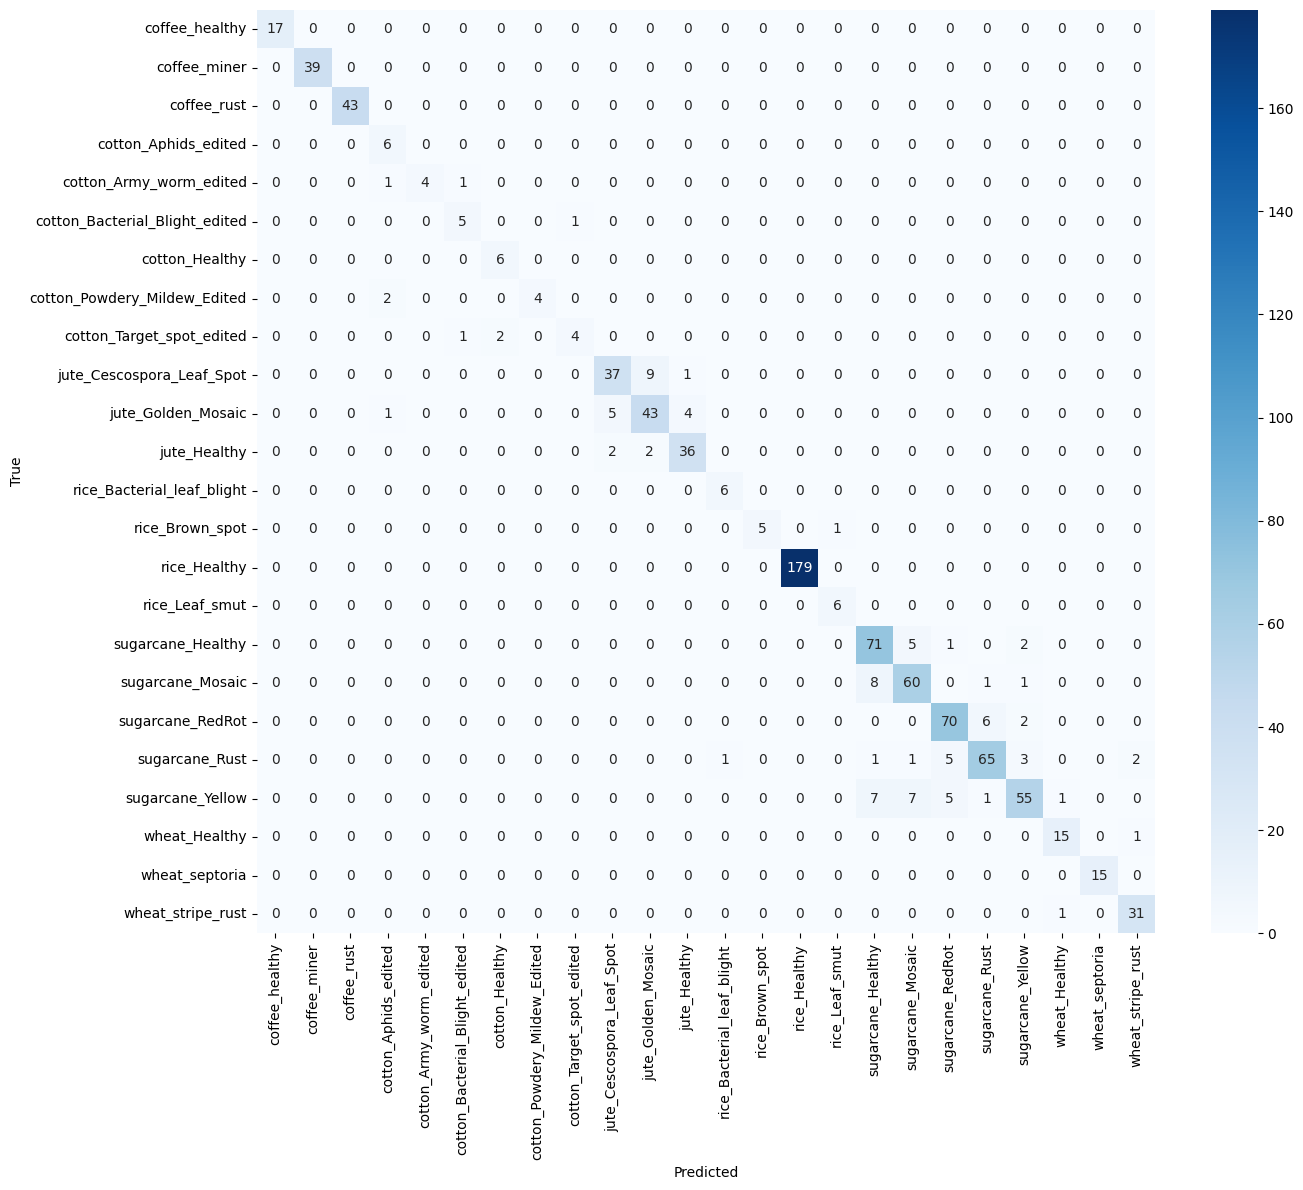

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_gen.reset()
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

In [22]:
model.save("/content/crop_disease_model.keras")
print("✅ Model saved")
files.download("/content/crop_disease_model.keras")

✅ Model saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>